### STEP1: Loading Dataset

In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [2]:
!kaggle datasets download -d rmisra/news-category-dataset

Dataset URL: https://www.kaggle.com/datasets/rmisra/news-category-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 26.5M/26.5M [00:03<00:00, 7.99MB/s]



In [4]:
import pandas as pd
import json

# 1. Unzip the downloaded file (if you haven't already via Kaggle's UI)
!unzip /content/news-category-dataset.zip

# 2. Load the JSON data
data = []
with open('/content/News_Category_Dataset_v3.json', 'r') as f:
    for line in f:
        data.append(json.loads(line))

# 3. Convert to DataFrame
df = pd.DataFrame(data)

# 4. Quick Look
print(f"Dataset Shape: {df.shape}")
df.head()

Archive:  /content/news-category-dataset.zip
  inflating: News_Category_Dataset_v3.json  
Dataset Shape: (209527, 6)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


### STEP2: Basic EDA + Data Understanding

In [5]:
print("Shape:", df.shape)
print("Columns:", df.columns)

Shape: (209527, 6)
Columns: Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='object')


In [6]:
# check missing values
df.isnull().sum()

,0
link,0
headline,0
category,0
short_description,0
authors,0
date,0


In [7]:
# Combining text fields to create a single text column
df['text'] = df['headline'] + " " + df['short_description']
df[['text', 'category']].head()

,text,category
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY
3,The Funniest Tweets From Parents This Week (Se...,PARENTING
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS


In [8]:
import re

def clean_text(text):
    text = text.lower() # Lowercase
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra whitespace
    return text

df['text'] = df['text'].apply(clean_text)

In [9]:
# Check number of categories
df['category'].unique()

array(['U.S. NEWS', 'COMEDY', 'PARENTING', 'WORLD NEWS', 'CULTURE & ARTS',
       'TECH', 'SPORTS', 'ENTERTAINMENT', 'POLITICS', 'WEIRD NEWS',
       'ENVIRONMENT', 'EDUCATION', 'CRIME', 'SCIENCE', 'WELLNESS',
       'BUSINESS', 'STYLE & BEAUTY', 'FOOD & DRINK', 'MEDIA',
       'QUEER VOICES', 'HOME & LIVING', 'WOMEN', 'BLACK VOICES', 'TRAVEL',
       'MONEY', 'RELIGION', 'LATINO VOICES', 'IMPACT', 'WEDDINGS',
       'COLLEGE', 'PARENTS', 'ARTS & CULTURE', 'STYLE', 'GREEN', 'TASTE',
       'HEALTHY LIVING', 'THE WORLDPOST', 'GOOD NEWS', 'WORLDPOST',
       'FIFTY', 'ARTS', 'DIVORCE'], dtype=object)

In [10]:
df['category'].value_counts()

,count
category,
POLITICS,35602
WELLNESS,17945
ENTERTAINMENT,17362
TRAVEL,9900
STYLE & BEAUTY,9814
PARENTING,8791
HEALTHY LIVING,6694
QUEER VOICES,6347
FOOD & DRINK,6340


In [11]:
# This dataset has too many categories around ~40, we'll keep top 10 categories for now
# Get the names of the top 10 categories
top_10_categories = df['category'].value_counts().nlargest(10).index.tolist()

# Filter the dataframe
df_top = df[df['category'].isin(top_10_categories)].copy()

# Important: Re-map your labels so they go from 0 to 9
cat_to_idx = {cat: i for i, cat in enumerate(top_10_categories)}
df_top['label'] = df_top['category'].map(cat_to_idx)

print(f"New dataset shape: {df_top.shape}")
print(f"Categories: {top_10_categories}")

New dataset shape: (124787, 8)
Categories: ['POLITICS', 'WELLNESS', 'ENTERTAINMENT', 'TRAVEL', 'STYLE & BEAUTY', 'PARENTING', 'HEALTHY LIVING', 'QUEER VOICES', 'FOOD & DRINK', 'BUSINESS']


In [12]:
# Create a mapping from category name to ID
categories = df['category'].unique()
cat_to_idx = {cat: i for i, cat in enumerate(categories)}
idx_to_cat = {i: cat for cat, i in cat_to_idx.items()}

df['label'] = df['category'].map(cat_to_idx)
num_classes = len(categories)
print(f"Total Unique Classes: {num_classes}")

Total Unique Classes: 42


### STEP 3: Train/Test Split + Tokenization

In [13]:
from sklearn.model_selection import train_test_split

# Splitting 80% Train, 20% Test
train_df, test_df = train_test_split(df_top, test_size=0.2, random_state=42, stratify=df_top['label'])

print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")

Train size: 99829 | Test size: 24958


In [14]:
# Simple Tokenization & Vocab Building, where a dictionary that maps unique word to unique integer

from collections import Counter

def build_vocab(sentences, max_vocab_size=10000):
    words = []
    for sent in sentences:
        words.extend(sent.split())

    # Get most common words to limit memory usage
    counts = Counter(words)
    common_words = counts.most_common(max_vocab_size - 2) # -2 for PAD and UNK

    # 0 is usually PAD, 1 is usually UNK (Unknown)
    vocab = {word: i+2 for i, (word, _) in enumerate(common_words)}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab

# Build vocab using ONLY training data
vocabulary = build_vocab(train_df['text'])
VOCAB_SIZE = len(vocabulary)
print(f"Vocabulary size: {VOCAB_SIZE}")

Vocabulary size: 10000


In [15]:
# Numericalizing & Padding
# LSTMs require batches of the same length. We pick a MAX_LEN (e.g., 50 words for headlines + descriptions)
# and pad shorter sequences with zeros or truncate longer ones.
import torch

def tokenize_and_pad(text, vocab, max_len=50):
    # Convert words to IDs, use 1 (UNK) if word not in vocab
    tokens = [vocab.get(word, 1) for word in text.split()]

    # Truncate or Pad
    if len(tokens) > max_len:
        tokens = tokens[:max_len]
    else:
        tokens = tokens + [0] * (max_len - len(tokens))

    return torch.tensor(tokens)

# Apply to datasets
X_train = torch.stack([tokenize_and_pad(t, vocabulary) for t in train_df['text']])
y_train = torch.tensor(train_df['label'].values)

X_test = torch.stack([tokenize_and_pad(t, vocabulary) for t in test_df['text']])
y_test = torch.tensor(test_df['label'].values)

print(f"X_train shape: {X_train.shape}") # Should be (N, 50)

# added stratify in the split. Since news categories are still slightly
# imbalanced even in the top 10, this ensures the ratio of "POLITICS" to
# "ENTERTAINMENT" stays the same in both your training and testing sets.
# Without this, your test results might be misleading.

X_train shape: torch.Size([99829, 50])


In [ ]:
# In PyTorch, the DataLoader is the "engine" that handles shuffling your data
# (so the model doesn't just learn the order of the news articles) and grouping them into batches. Feeding the entire
# dataset into the GPU/CPU at once would likely crash memory, so we process it in smaller chunks.

### STEP 4: DataLoaders and Model Initialization

In [20]:
from torch.utils.data import TensorDataset, DataLoader

# 1. Create TensorDatasets
train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)

# 2. Define Batch Size
BATCH_SIZE = 200

# 3. Create DataLoaders
# Shuffle is TRUE for training to help the model generalize
train_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE)

# Shuffle is FALSE for testing to keep evaluation consistent
test_loader = DataLoader(test_data, shuffle=False, batch_size=BATCH_SIZE)

print(f"Number of batches in Train Loader: {len(train_loader)}")

Number of batches in Train Loader: 500


### STEP 4: Build Custom SLM (Embedding + LSTM)

In [21]:
import torch
import torch.nn as nn

class NewsSLM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2):
        super(NewsSLM, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # LSTM layer
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            # Dropout only applies between layers, so it needs num_layers > 1
            dropout=0.3 if num_layers > 1 else 0,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        # Linear layer: hidden_dim * 2 because it's bidirectional (forward + backward)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)

        # lstm_out: (batch, seq_len, hidden_dim * 2)
        # hidden state shape: (num_layers * 2, batch, hidden_dim)
        _, (hidden, _) = self.lstm(embedded)

        # Concatenate the final forward and backward hidden states from the last layer
        # hidden[-2, :, :] is the last layer's forward pass
        # hidden[-1, :, :] is the last layer's backward pass
        combined = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)

        out = self.dropout(combined)
        return self.fc(out)

In [22]:
import torch.optim as optim

# Hyperparameters based on your data
VOCAB_SIZE = len(vocabulary) # From our Step 3
EMBED_DIM = 128              # Size of word vectors (common range: 100-300)
HIDDEN_DIM = 256             # Number of LSTM units
NUM_CLASSES = 10             # Since we filtered for Top 10

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize Model
model = NewsSLM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

NewsSLM(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=10, bias=True)
)


### STEP 5: Training Loop + Accuracy Tracking



In [24]:
import torch.nn as nn
import torch.optim as optim

if torch.cuda.is_available():
    print("CUDA is available!")
else:
    print("CUDA is not available.")


# 1. Re-initialize Optimizer with Weight Decay (L2 Regularization)
# This helps prevent the "Loss: 0.07" over-memorization you saw
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# 2. Tracking variables
best_accuracy = 0
EPOCHS = 5

print(f"Starting training on {device}...")

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # --- VALIDATION PHASE ---
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for texts, labels in test_loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    accuracy = 100 * correct / total

    # 3. Save the BEST model based on Validation Accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'best_news_model.pth')
        status = "--> Model Saved!"
    else:
        status = ""

    print(f'Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_train_loss:.4f} | Acc: {accuracy:.2f}% {status}')

print(f'\nTraining Complete! Highest Accuracy achieved: {best_accuracy:.2f}%')

CUDA is available!
Starting training on cuda...
Epoch [1/5] | Loss: 0.6353 | Acc: 78.74% --> Model Saved!
Epoch [2/5] | Loss: 0.5291 | Acc: 79.66% --> Model Saved!
Epoch [3/5] | Loss: 0.4471 | Acc: 80.14% --> Model Saved!
Epoch [4/5] | Loss: 0.3749 | Acc: 79.95% 
Epoch [5/5] | Loss: 0.3090 | Acc: 80.27% --> Model Saved!

Training Complete! Highest Accuracy achieved: 80.27%


In [25]:
# Test the Model

def predict_news(text):
    model.load_state_dict(torch.load('best_news_model.pth'))
    model.eval()

    # 1. Clean and tokenize (matching your Step 2/3 logic)
    text = text.lower()
    tokens = [vocabulary.get(word, 1) for word in text.split()]

    # 2. Pad/Truncate to 50 (matching your MAX_LEN)
    if len(tokens) > 50:
        tokens = tokens[:50]
    else:
        tokens = tokens + [0] * (50 - len(tokens))

    # 3. Convert to tensor and move to device
    input_tensor = torch.tensor(tokens).unsqueeze(0).to(device) # unsqueeze adds batch dim

    # 4. Predict
    with torch.no_grad():
        output = model(input_tensor)
        _, predicted = torch.max(output, 1)

    category = idx_to_cat[predicted.item()]
    return category

# --- TEST IT ---
my_headline = "Government announces new tax cuts for small businesses" # Try yours here!
print(f"Headline: {my_headline}")
print(f"Predicted Category: {predict_news(my_headline)}")

Headline: Government announces new tax cuts for small businesses
Predicted Category: WEIRD NEWS


In [ ]:
# STEP 6: Transitioning to DistilBERT
# To use DistilBERT, we replace your manual vocabulary and nn.Embedding with the Hugging Face Transformers library

In [26]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch

In [ ]:
# Instead of building a class from nn.Module, we can use a pre-built sequence classifier.
# This automatically adds a dropout layer and a linear classification head on top of the transformer.

In [27]:
# Load the pre-trained tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=10  # Your top 10 categories
)

model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [29]:
# 3. Updated Tokenization
# DistilBERT doesnt just look at words; it uses "Sub-word tokenization." For example,
# the word "unhappiness" might be split into un, happi, and ness. This solves the "Unknown Word"
# problem you have with the BiLSTM.

from torch.utils.data import DataLoader

def bert_tokenize(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=64, # Slightly longer for news context
        return_tensors='pt'
    )

# Apply to your top 10 dataframe
train_encodings = bert_tokenize(train_df['text'])
test_encodings = bert_tokenize(test_df['text'])

# Create a clean Dataset class for PyTorch
# 1. Re-define the Dataset to be explicitly clear
class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # This returns a dictionary of tensors for a single index
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# 2. Re-create the encodings (Ensure they are not already tensors)
train_encodings = tokenizer(train_df['text'].tolist(), truncation=True, padding=True, max_length=64)
test_encodings = tokenizer(test_df['text'].tolist(), truncation=True, padding=True, max_length=64)

# 3. Initialize the Datasets
train_dataset = NewsDataset(train_encodings, train_df['label'].values)
test_dataset = NewsDataset(test_encodings, test_df['label'].values)

# 4. Create the DataLoaders with the larger Colab batch size
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [31]:
import time
import gc
import torch
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# --- Setup ---
gc.collect()
torch.cuda.empty_cache()

optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
epochs = 3
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# Metrics & Best Model Tracking
train_loss_list = []
val_acc_list = []
best_val_acc = 0.0
val_size = len(test_loader.dataset)

print(f"Starting Fine-Tuning on {device}...")

for epoch in range(epochs):
    start_time = time.time()

    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0

    for step, batch in enumerate(train_loader):
        b_input_ids = batch['input_ids'].to(device)
        b_input_mask = batch['attention_mask'].to(device)
        b_labels = batch['labels'].to(device)

        model.zero_grad()

        outputs = model(
            b_input_ids,
            attention_mask=b_input_mask,
            labels=b_labels
        )

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        # Reduced frequency of prints to keep output clean
        if step % 5000 == 0:
            print(f"  Epoch {epoch+1} | Step {step}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_list.append(avg_train_loss)

    # --- VALIDATION PHASE ---
    model.eval()
    val_correct = 0

    for batch in test_loader:
        b_input_ids = batch['input_ids'].to(device)
        b_input_mask = batch['attention_mask'].to(device)
        b_labels = batch['labels'].to(device)

        with torch.no_grad():
            outputs = model(b_input_ids, attention_mask=b_input_mask)

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)
        val_correct += (preds == b_labels).sum().item()

    val_acc = val_correct / val_size
    val_acc_list.append(val_acc)
    epoch_time = time.time() - start_time

    # --- SAVE BEST MODEL LOGIC ---
    save_msg = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_distilbert_news.pth')
        save_msg = " --> [Best Model Saved!]"

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Time: {epoch_time:.1f}s{save_msg}")

print(f"\nTraining Complete! Best Accuracy: {best_val_acc*100:.2f}%")

Starting Fine-Tuning on cuda...
  Epoch 1 | Step 0/3120 | Loss: 1.8786
Epoch 1/3 | Train Loss: 0.5817 | Val Acc: 85.15% | Time: 653.1s --> [Best Model Saved!]
  Epoch 2 | Step 0/3120 | Loss: 0.4376
Epoch 2/3 | Train Loss: 0.3648 | Val Acc: 86.19% | Time: 651.1s --> [Best Model Saved!]
  Epoch 3 | Step 0/3120 | Loss: 0.2285
Epoch 3/3 | Train Loss: 0.2676 | Val Acc: 86.06% | Time: 651.7s

Training Complete! Best Accuracy: 86.19%


Running evaluation on test set using the BEST saved model...

FINAL PERFORMANCE METRICS
                precision    recall  f1-score   support

      POLITICS       0.93      0.93      0.93      7121
      WELLNESS       0.77      0.87      0.82      3589
 ENTERTAINMENT       0.90      0.90      0.90      3473
        TRAVEL       0.90      0.88      0.89      1980
STYLE & BEAUTY       0.92      0.90      0.91      1963
     PARENTING       0.81      0.86      0.84      1758
HEALTHY LIVING       0.67      0.46      0.55      1339
  QUEER VOICES       0.85      0.81      0.83      1269
  FOOD & DRINK       0.86      0.91      0.88      1268
      BUSINESS       0.76      0.68      0.72      1198

      accuracy                           0.86     24958
     macro avg       0.84      0.82      0.83     24958
  weighted avg       0.86      0.86      0.86     24958



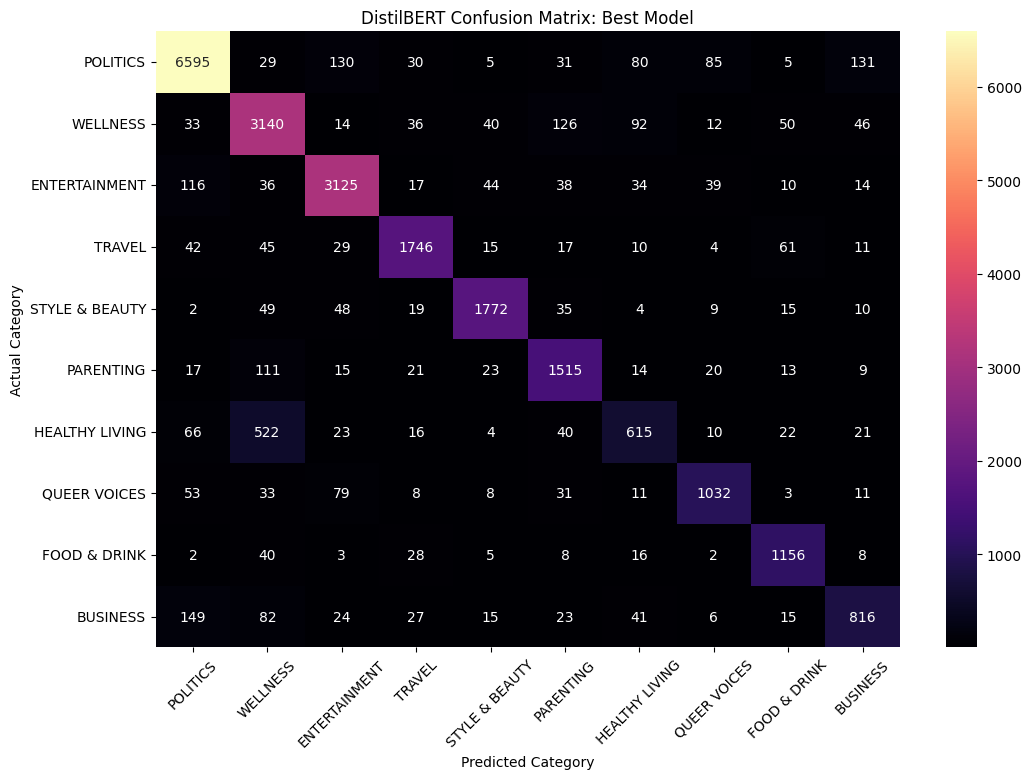

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# 1. LOAD THE BEST SAVED WEIGHTS
# This ensures you are evaluating the peak performance, not just the last epoch
model.load_state_dict(torch.load('best_distilbert_news.pth'))
model.to(device)
model.eval()

all_preds = []
all_labels = []

print("Running evaluation on test set using the BEST saved model...")

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. Final Performance Report
print("\n" + "="*30)
print("FINAL PERFORMANCE METRICS")
print("="*30)
# Ensure top_10_categories is defined from your earlier filtering step
print(classification_report(all_labels, all_preds, target_names=top_10_categories))

# 3. Heatmap Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
            xticklabels=top_10_categories,
            yticklabels=top_10_categories)

plt.title('DistilBERT Confusion Matrix: Best Model')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.xticks(rotation=45)
plt.show()

In [35]:
def predict_real_time(headline):
    # 1. Load best model
    model.load_state_dict(torch.load('best_distilbert_news.pth'))
    model.eval()
    model.to(device)

    # 2. Tokenize the headline
    inputs = tokenizer(headline, return_tensors="pt", truncation=True, padding=True, max_length=64)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 3. Get prediction
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        conf, pred = torch.max(probs, dim=1)

    category = top_10_categories[pred.item()]
    print(f"Headline: {headline}")
    print(f"Prediction: {category} ({conf.item()*100:.2f}% Confidence)")

# --- TRY IT OUT ---
predict_real_time("New study reveals the best superfoods for heart health")
predict_real_time("Stock market rallies as tech earnings beat expectations")

Headline: New study reveals the best superfoods for heart health
Prediction: HEALTHY LIVING (97.46% Confidence)
Headline: Stock market rallies as tech earnings beat expectations
Prediction: BUSINESS (89.57% Confidence)


In [34]:
from torchviz import make_dot

batch = next(iter(train_loader))

b_input_ids = batch['input_ids'].to(device)
b_input_mask = batch['attention_mask'].to(device)

outputs = model(b_input_ids, attention_mask=b_input_mask)

graph = make_dot(outputs.logits, params=dict(model.named_parameters()))
graph.render("bert_computation_graph", format="png")

'bert_computation_graph.png'